<a href="https://colab.research.google.com/github/mrJay188/AI-ML/blob/main/Scaling_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Feature Scaling**

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.shape

(891, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
df2 = df[['survived','pclass','age','parch']]
df2.head()

,survived,pclass,age,parch
0,0,3,22.0,0
1,1,1,38.0,0
2,1,3,26.0,0
3,1,1,35.0,0
4,0,3,35.0,0


In [ ]:
df2.isnull().sum()

,0
survived,0
pclass,0
age,177
parch,0


In [ ]:
df2['pclass'].mean()

np.float64(2.308641975308642)

In [ ]:
df2['age'].mean()

np.float64(29.69911764705882)

In [ ]:
df2.describe()

,survived,pclass,age,parch
count,891.000000,891.000000,714.000000,891.000000
mean,0.383838,2.308642,29.699118,0.381594
std,0.486592,0.836071,14.526497,0.806057
min,0.000000,1.000000,0.420000,0.000000
25%,0.000000,2.000000,20.125000,0.000000
50%,0.000000,3.000000,28.000000,0.000000
75%,1.000000,3.000000,38.000000,0.000000
max,1.000000,3.000000,80.000000,6.000000


In [ ]:
df_fill = df2.fillna(df2.mean())
df_fill.head()

,survived,pclass,age,parch
0,0,3,22.0,0
1,1,1,38.0,0
2,1,3,26.0,0
3,1,1,35.0,0
4,0,3,35.0,0


In [ ]:
x = df_fill.drop('survived',axis=1)
y = df_fill['survived']

In [ ]:
print('Shape of x : ',x.shape)
print('Shape of y : ',y.shape)

Shape of x :  (891, 3)
Shape of y :  (891,)


**Train Test **

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=51)

In [ ]:
print('Shape of x_train : ',x_train.shape)
print('Shape of y_train : ',y_train.shape)
print('Shape of x_test : ',x_test.shape)
print('Shape of y_test : ',y_test.shape)

Shape of x_train :  (712, 3)
Shape of y_train :  (712,)
Shape of x_test :  (179, 3)
Shape of y_test :  (179,)


In [ ]:
sc = StandardScaler()

In [ ]:
sc.fit(x_train)

StandardScaler()

In [ ]:
sc.mean_

array([ 2.30617978, 29.55409121,  0.39185393])

In [ ]:
x_train.describe()

,pclass,age,parch
count,712.000000,712.000000,712.000000
mean,2.306180,29.554091,0.391854
std,0.844651,13.000763,0.797035
min,1.000000,0.420000,0.000000
25%,1.750000,22.000000,0.000000
50%,3.000000,29.699118,0.000000
75%,3.000000,35.000000,0.000000
max,3.000000,71.000000,5.000000


In [ ]:
sc.transform(x_train)

array([[ 0.8220055 , -0.42751304, -0.49198545],
       [ 0.8220055 ,  1.997125  , -0.49198545],
       [ 0.8220055 , -1.42815732, -0.49198545],
       ...,
       [ 0.8220055 ,  1.41983023,  3.27461284],
       [ 0.8220055 ,  0.01116307,  0.76354731],
       [ 0.8220055 , -0.08113618, -0.49198545]])

In [ ]:
x_train_sc = sc.transform(x_train)
x_test_sc = sc.transform(x_test)

In [ ]:
x_train

,pclass,age,parch
770,3,24.000000,0
152,3,55.500000,0
731,3,11.000000,0
775,3,18.000000,0
324,3,29.699118,2
...,...,...,...
528,3,39.000000,0
709,3,29.699118,1
736,3,48.000000,3
485,3,29.699118,1


In [ ]:
x_train_sc = pd.DataFrame(x_train_sc,columns=['pclass','age','parch'])
x_test_sc = pd.DataFrame(x_test_sc,columns=['pclass','age','parch'])

In [ ]:
x_test_sc

,pclass,age,parch
0,-1.547500,0.804049,-0.491985
1,0.822005,0.188268,-0.491985
2,0.822005,0.034323,-0.491985
3,-1.547500,0.011163,-0.491985
4,-0.362747,0.342213,0.763547
...,...,...,...
174,0.822005,0.011163,2.019080
175,0.822005,-0.273568,-0.491985
176,-0.362747,-0.427513,-0.491985
177,-1.547500,0.111295,-0.491985


In [ ]:
x_train_sc.describe()

,pclass,age,parch
count,7.120000e+02,7.120000e+02,7.120000e+02
mean,1.160121e-16,1.521879e-16,6.237208e-17
std,1.000703e+00,1.000703e+00,1.000703e+00
min,-1.547500e+00,-2.242528e+00,-4.919855e-01
25%,-6.589356e-01,-5.814583e-01,-4.919855e-01
50%,8.220055e-01,1.116307e-02,-4.919855e-01
75%,8.220055e-01,4.191860e-01,-4.919855e-01
max,8.220055e-01,3.190201e+00,5.785678e+00


In [ ]:
x_train.describe()

,pclass,age,parch
count,712.000000,712.000000,712.000000
mean,2.306180,29.554091,0.391854
std,0.844651,13.000763,0.797035
min,1.000000,0.420000,0.000000
25%,1.750000,22.000000,0.000000
50%,3.000000,29.699118,0.000000
75%,3.000000,35.000000,0.000000
max,3.000000,71.000000,5.000000


In [ ]:
x_test_sc

,pclass,age,parch
0,-1.547500,0.804049,-0.491985
1,0.822005,0.188268,-0.491985
2,0.822005,0.034323,-0.491985
3,-1.547500,0.011163,-0.491985
4,-0.362747,0.342213,0.763547
...,...,...,...
174,0.822005,0.011163,2.019080
175,0.822005,-0.273568,-0.491985
176,-0.362747,-0.427513,-0.491985
177,-1.547500,0.111295,-0.491985


In [ ]:
x_test.describe()

,pclass,age,parch
count,179.000000,179.000000,179.000000
mean,2.318436,30.275983,0.340782
std,0.803256,13.027411,0.842056
min,1.000000,0.830000,0.000000
25%,2.000000,23.500000,0.000000
50%,3.000000,29.699118,0.000000
75%,3.000000,35.000000,0.000000
max,3.000000,80.000000,6.000000


**MinMaxAcaler**

In [ ]:
mnc = MinMaxScaler()

In [ ]:
x_test_mnc = mnc.fit_transform(x_test)
x_train_mnc = mnc.fit_transform(x_train)

In [ ]:
x_train_mnc = pd.DataFrame(x_train_sc,columns=['pclass','age','parch'])
x_test_mnc = pd.DataFrame(x_test_sc,columns=['pclass','age','parch'])

In [ ]:
x_train_mnc

,pclass,age,parch
0,0.822005,-0.427513,-0.491985
1,0.822005,1.997125,-0.491985
2,0.822005,-1.428157,-0.491985
3,0.822005,-0.889349,-0.491985
4,0.822005,0.011163,2.019080
...,...,...,...
707,0.822005,0.727077,-0.491985
708,0.822005,0.011163,0.763547
709,0.822005,1.419830,3.274613
710,0.822005,0.011163,0.763547


In [ ]:
x_test_mnc

,pclass,age,parch
0,-1.547500,0.804049,-0.491985
1,0.822005,0.188268,-0.491985
2,0.822005,0.034323,-0.491985
3,-1.547500,0.011163,-0.491985
4,-0.362747,0.342213,0.763547
...,...,...,...
174,0.822005,0.011163,2.019080
175,0.822005,-0.273568,-0.491985
176,-0.362747,-0.427513,-0.491985
177,-1.547500,0.111295,-0.491985


In [ ]:
x_train_mnc.describe()

,pclass,age,parch
count,7.120000e+02,7.120000e+02,7.120000e+02
mean,1.160121e-16,1.521879e-16,6.237208e-17
std,1.000703e+00,1.000703e+00,1.000703e+00
min,-1.547500e+00,-2.242528e+00,-4.919855e-01
25%,-6.589356e-01,-5.814583e-01,-4.919855e-01
50%,8.220055e-01,1.116307e-02,-4.919855e-01
75%,8.220055e-01,4.191860e-01,-4.919855e-01
max,8.220055e-01,3.190201e+00,5.785678e+00


In [ ]:
x_test_mnc.describe()

,pclass,age,parch
count,179.000000,179.000000,179.000000
mean,0.014520,0.055566,-0.064122
std,0.951660,1.002754,1.057229
min,-1.547500,-2.210969,-0.491985
25%,-0.362747,-0.465999,-0.491985
50%,0.822005,0.011163,-0.491985
75%,0.822005,0.419186,-0.491985
max,0.822005,3.882955,7.041211


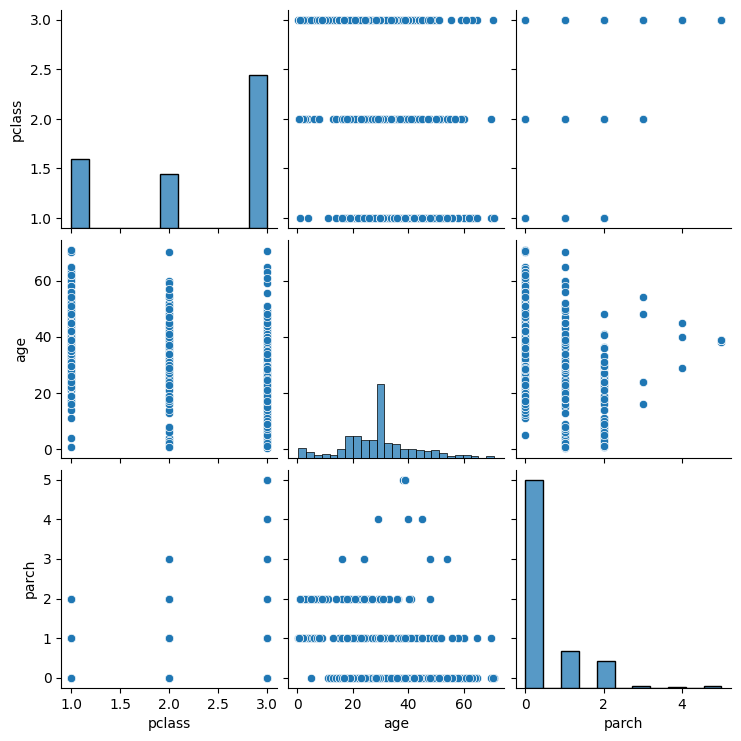

In [ ]:
sns.pairplot(x_train)

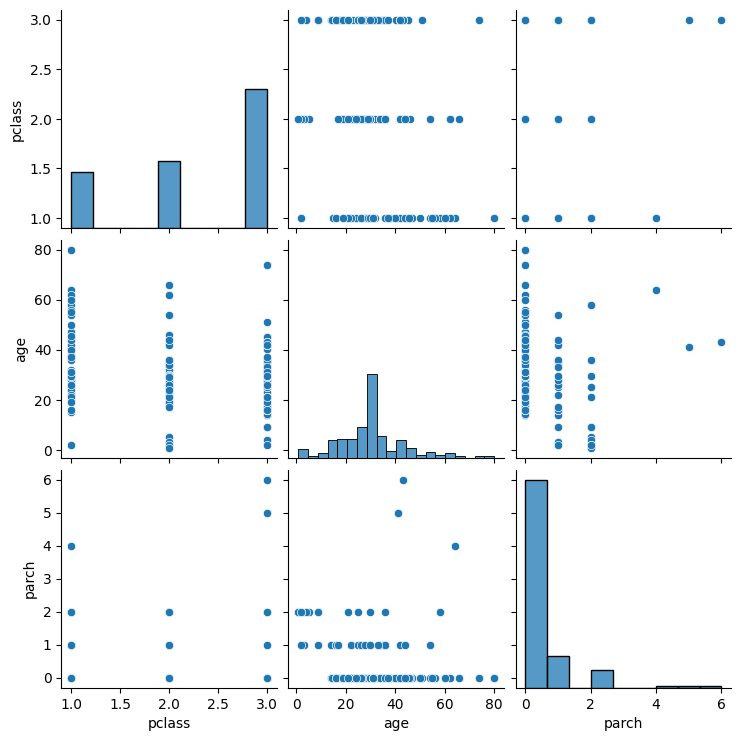

In [ ]:
sns.pairplot(x_test)

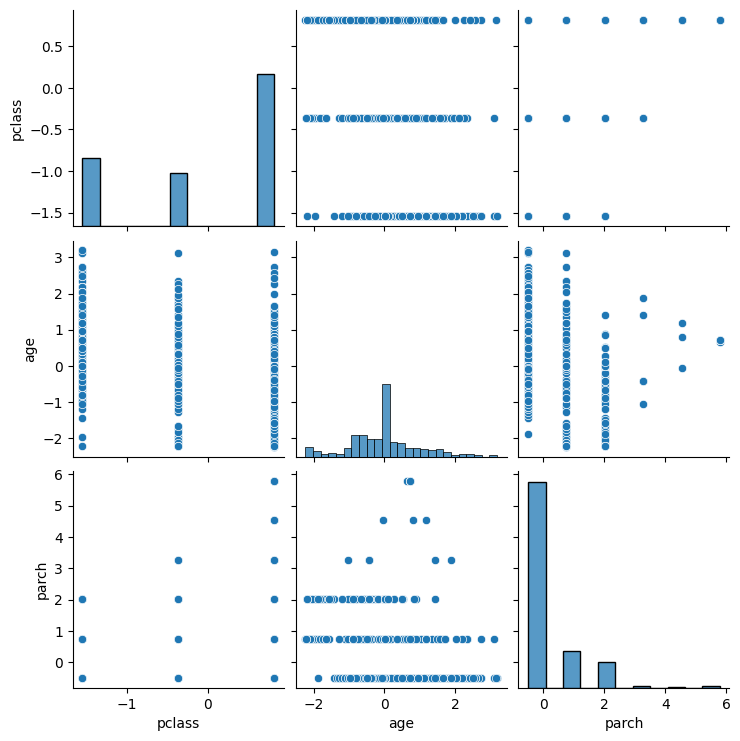

In [ ]:
sns.pairplot(x_train_sc)


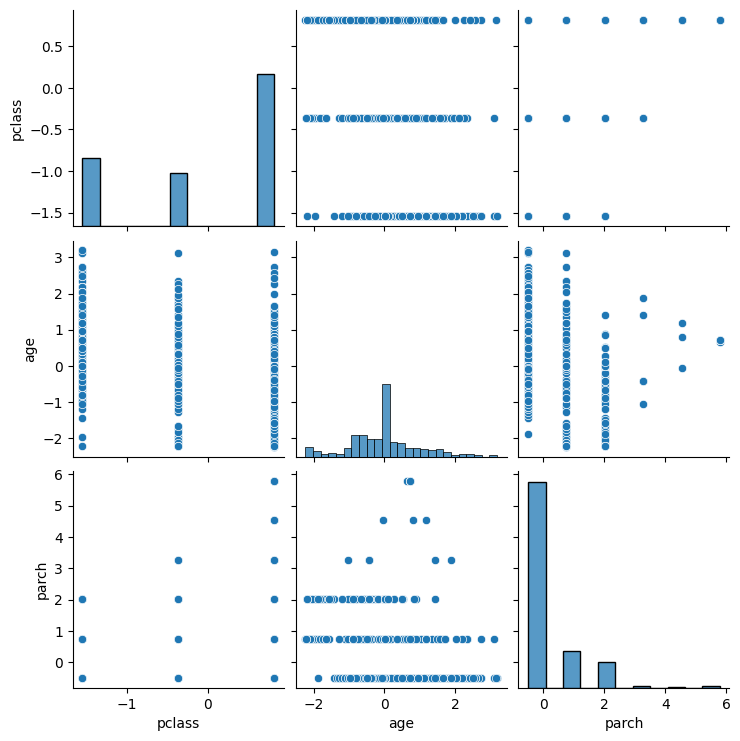

In [ ]:
sns.pairplot(x_train_sc)


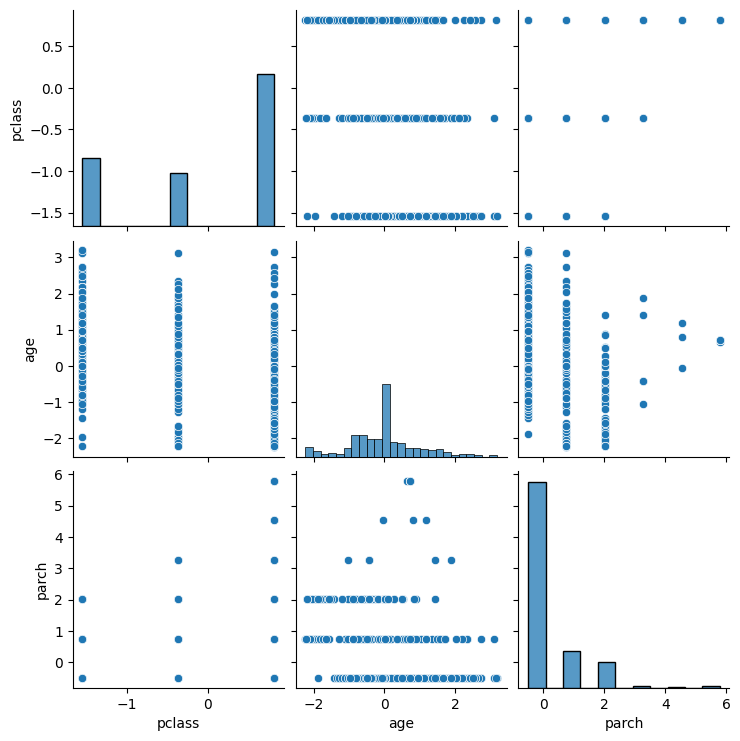

In [ ]:
sns.pairplot(x_train_mnc)


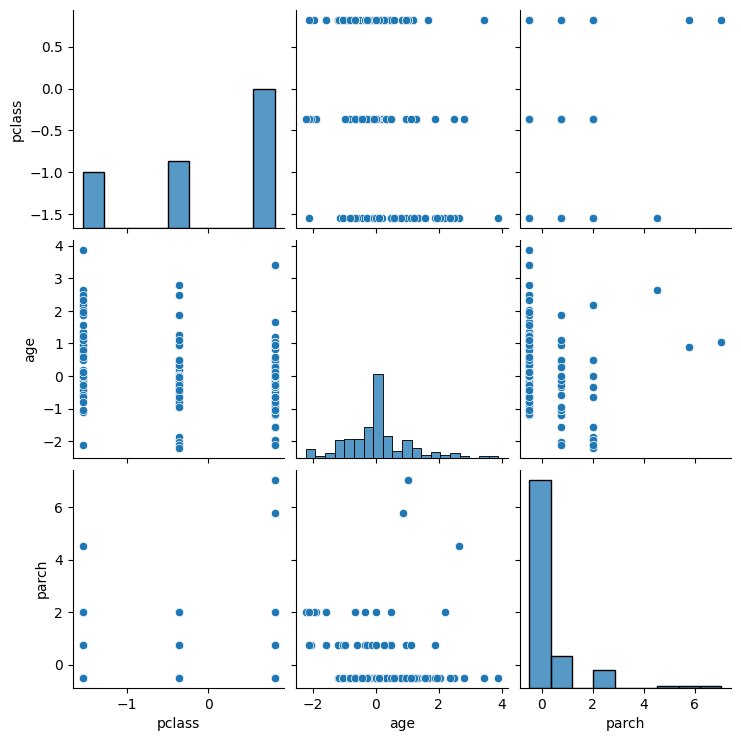

In [ ]:
sns.pairplot(x_test_mnc)
